# 03: Baseline: TF-IDF + Logistic Regression

**Why this model?** TF-IDF + logistic regression is a standard first baseline for text classification. It's fast to train, interpretable, and strong on small datasets like ours (1,109 rows). It sets a floor — if a fancier model can't beat this, it's not worth the complexity.

**How it works:** TF-IDF converts each document into a vector of word importance scores — words that appear often in one document but rarely across all documents get high scores. Logistic regression then learns which words (and word pairs) are most predictive of each category. `class_weight="balanced"` ensures the model doesn't ignore smaller classes.

**Steps:**
1. TF-IDF vectorise `text_clean` (5000 features, unigrams + bigrams, English stopwords removed)
2. Combine with one-hot metadata features (`item_type`, `org_broad_category`)
3. Train logistic regression with `class_weight="balanced"`
4. Evaluate: macro F1, per-class precision/recall, confusion matrix
5. Compare text-only vs text + metadata — does metadata help?
6. Inspect top features per class (LogReg coefficients)
7. Save model + vectoriser for later comparison

**Input:** `data/modelling/train.csv`, `data/modelling/val.csv` (from `02_preprocessing.ipynb`)


# 0. Data and Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from scipy.sparse import hstack # hstack joins sparse TF-IDF with dense metadata without expanding the sparse matrix
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve

In [2]:
DATA_DIR = Path("../data/modelling")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

# 1. Load data

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")

with open(DATA_DIR / "metadata_columns.json") as f:
    metadata_cols = json.load(f)

print(f"Train: {train_df.shape[0]} rows")
print(f"Val:   {val_df.shape[0]} rows")
print(f"Metadata features: {len(metadata_cols)}")
print(f"\nTarget distribution (train):\n{train_df['target'].value_counts()}")

Train: 942 rows
Val:   167 rows
Metadata features: 17

Target distribution (train):
target
political_environment_key_organisations    203
what_matters_ed                            167
teacher_rrd                                165
edtech                                     149
policy_practice_research                   136
four_nations                               122
Name: count, dtype: int64


#### Mild imbalance (13–21%) — `class_weight="balanced"` will handle this.

# 2. TF-IDF vectorisation

In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # 3+ letter words only
)

X_train_tfidf = tfidf.fit_transform(train_df["text_clean"])
X_val_tfidf = tfidf.transform(val_df["text_clean"])

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF shape: (942, 4453)
Vocabulary size: 4453


# 3. Combine TF-IDF with metadata features

In [5]:
X_train_meta = train_df[metadata_cols].values
X_val_meta = val_df[metadata_cols].values

X_train = hstack([X_train_tfidf, X_train_meta])
X_val = hstack([X_val_tfidf, X_val_meta])

y_train = train_df["target"]
y_val = val_df["target"]

print(f"Combined feature matrix: {X_train.shape}")
print(f"  TF-IDF: {X_train_tfidf.shape[1]}  |  Metadata: {X_train_meta.shape[1]}")

Combined feature matrix: (942, 4470)
  TF-IDF: 4453  |  Metadata: 17


# 4. Train logistic regression

In [6]:
clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED,
    C=1.0,
)

clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.3f}")
print(f"Val accuracy:   {clf.score(X_val, y_val):.3f}")

Train accuracy: 0.911
Val accuracy:   0.617


#### Overfitting as expected for a baseline - 91% train vs 62% val. The val score is our benchmark to beat with later models. No tuning needed now.


# 5. Evaluate

In [7]:
y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.3f}\n")
print(classification_report(y_val, y_pred))

Macro F1: 0.611

                                         precision    recall  f1-score   support

                                 edtech       0.58      0.42      0.49        26
                           four_nations       0.62      0.91      0.74        22
               policy_practice_research       0.58      0.62      0.60        24
political_environment_key_organisations       0.70      0.39      0.50        36
                            teacher_rrd       0.65      0.76      0.70        29
                        what_matters_ed       0.58      0.70      0.64        30

                               accuracy                           0.62       167
                              macro avg       0.62      0.63      0.61       167
                           weighted avg       0.62      0.62      0.60       167



**For our use case, recall matters more than precision.** The curator can quickly remove a wrong suggestion, but can't easily find an article that was buried in the wrong category.


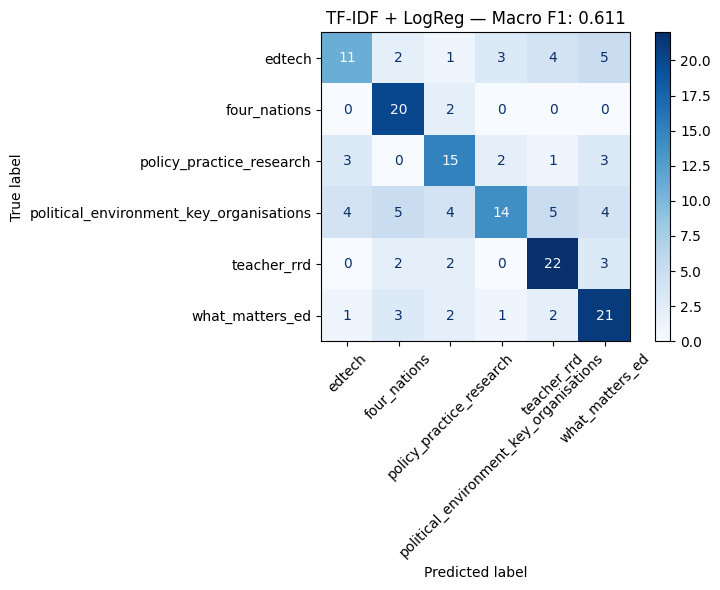

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"TF-IDF + LogReg — Macro F1: {macro_f1:.3f}")
plt.tight_layout()
plt.show()

In [9]:
# Get predicted probabilities for each class
y_proba = clf.predict_proba(X_val)
classes = clf.classes_

# Top-k accuracy
for k in [1, 2]:
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]
    top_k_correct = [
        np.where(classes == true)[0][0] in top_k
        for true, top_k in zip(y_val, top_k_preds)
    ]
    print(f"Top-{k} accuracy: {np.mean(top_k_correct):.3f}")

# Sample predictions (first 10 val rows)
print("\n--- Sample predictions (first 10 val rows) ---\n")
for i in range(10):
    true_label = y_val.iloc[i]
    top2_idx = np.argsort(y_proba[i])[-2:][::-1]
    top2 = [(classes[j], y_proba[i][j]) for j in top2_idx]

    match = "correct" if true_label == top2[0][0] else "WRONG"
    in_top2 = "in top 2" if true_label in [c for c, _ in top2] else "MISSED"

    print(f"True: {true_label}")
    print(f"  1. {top2[0][0]} ({top2[0][1]:.2f})  2. {top2[1][0]} ({top2[1][1]:.2f})")
    print(f"  → {match}, {in_top2}\n")

# Missed predictions
print("--- MISSED: true label not in top 2 ---\n")
for i in range(len(y_val)):
    true_label = y_val.iloc[i]
    top2_idx = np.argsort(y_proba[i])[-2:][::-1]
    top2 = [(classes[j], y_proba[i][j]) for j in top2_idx]

    if true_label not in [c for c, _ in top2]:
        print(f"True: {true_label}")
        print(f"  1. {top2[0][0]} ({top2[0][1]:.2f})  2. {top2[1][0]} ({top2[1][1]:.2f})")
        print(f"  Text: {val_df.iloc[i]['text_clean'][:150]}")
        print()


Top-1 accuracy: 0.617
Top-2 accuracy: 0.820

--- Sample predictions (first 10 val rows) ---

True: political_environment_key_organisations
  1. political_environment_key_organisations (0.37)  2. four_nations (0.37)
  → correct, in top 2

True: political_environment_key_organisations
  1. political_environment_key_organisations (0.31)  2. what_matters_ed (0.26)
  → correct, in top 2

True: teacher_rrd
  1. teacher_rrd (0.76)  2. policy_practice_research (0.08)
  → correct, in top 2

True: what_matters_ed
  1. what_matters_ed (0.48)  2. policy_practice_research (0.16)
  → correct, in top 2

True: political_environment_key_organisations
  1. political_environment_key_organisations (0.35)  2. policy_practice_research (0.15)
  → correct, in top 2

True: four_nations
  1. four_nations (0.69)  2. political_environment_key_organisations (0.11)
  → correct, in top 2

True: political_environment_key_organisations
  1. edtech (0.33)  2. teacher_rrd (0.21)
  → WRONG, MISSED

True: policy_practice_

In [10]:
# Per-class top-2 accuracy
print("Per-class top-2 accuracy:\n")
for cls in clf.classes_:
    mask = y_val == cls
    top2_preds = np.argsort(y_proba[mask], axis=1)[:, -2:]
    cls_idx = np.where(classes == cls)[0][0]
    hit_rate = np.mean([cls_idx in row for row in top2_preds])
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")


Per-class top-2 accuracy:

  edtech                                        73%  (26 samples)
  four_nations                                  95%  (22 samples)
  policy_practice_research                      75%  (24 samples)
  political_environment_key_organisations       72%  (36 samples)
  teacher_rrd                                   93%  (29 samples)
  what_matters_ed                               87%  (30 samples)


#### Note: Showing top 2 predictions captures 82% accuracy (up from 62% top-1) while keeping the curator's decision simple — adding a third only gains 7% more but adds noise.


### Analysis of missed predictions

30 articles where the true label wasn't in the top 2. Clear patterns emerge:

**1. Articles sit at the boundary of multiple categories**
Many of these are genuinely ambiguous — a human could reasonably argue for more than one label. For example:
- "Ofsted to review the use of AI in schools" — is this `edtech` (AI) or `political_environment` (Ofsted/DfE)?
- "Teacher-powered research: building evidence around everyday practice" — is this `teacher_rrd` or `policy_practice_research`?
- "Child poverty: Statistics, causes and the UK's policy response" — is this `what_matters_ed` or `political_environment`?

**2. `political_environment_key_organisations` is the most common true label in the missed set** — confirms it's a broad catch-all. Articles about DfE, Ofsted, OECD, Sutton Trust all fall here, but their *topics* (AI, teachers, early years) pull the model towards other categories.

**3. `edtech` articles get misclassified when they mention organisations** — the model sees "DfE", "Ofsted", "EEF" and predicts `political_environment` or `teacher_rrd`, missing that the core topic is technology.

**4. The model relies on keyword matching, not meaning** — it can't distinguish "Ofsted reviewing AI" (edtech) from "Ofsted reviewing schools" (political_environment) because both contain "Ofsted". This is exactly the limitation that sentence transformers and Claude API should improve on.

**Takeaway:** most misses aren't model errors so much as genuinely overlapping categories. The top-2 approach (82% accuracy) already handles most of the ambiguity. Semantic models in later notebooks should help with the remaining 18%.


### Interpretation

**Macro F1: 0.611** — reasonable baseline for 6 classes on a small dataset.

**Precision** = of everything the model *predicted* as this class, how many were right?  
**Recall** = of everything that *actually is* this class, how many did the model find?

**For our use case, recall matters more than precision.** The tool suggests categories for a curator — it's better to over-suggest (low precision: some wrong suggestions, curator removes them) than to miss articles (low recall: relevant articles buried in the wrong category, curator doesn't see them).

**Strongest classes:**
- `four_nations` (recall 91%) — the model catches almost all of them, likely thanks to distinctive vocabulary (Wales, Scotland, devolution)
- `teacher_rrd` (recall 76%) — good balance of precision and recall

**Weakest classes:**
- `political_environment_key_organisations` (recall 39%) — despite being the largest class, the model misses over half. This is a broad category that likely shares vocabulary with `policy_practice_research` and `what_matters_ed`
- `edtech` (recall 42%) — similar problem, vocabulary may overlap with other classes

**Implications for the pipeline:**
- Presenting the **top 3 predicted categories** (not just top 1) will help — even where top-1 recall is low, the correct category is likely in the top 3
- The two weakest classes may benefit most from the metadata features (`item_type`, `org_broad_category`) — worth checking in the text-only vs text+metadata comparison
- Later models (sentence transformers, Claude API) may handle the overlapping vocabulary better by understanding meaning rather than matching keywords


# 6. Compare: text-only vs text + metadata

Does adding `item_type` and `org_broad_category` help?

In [11]:
# Text-only model
clf_text_only = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=SEED
)
clf_text_only.fit(X_train_tfidf, y_train)
y_pred_text_only = clf_text_only.predict(X_val_tfidf)
f1_text_only = f1_score(y_val, y_pred_text_only, average="macro")

print(f"Text only     — Macro F1: {f1_text_only:.3f}")
print(f"Text + meta   — Macro F1: {macro_f1:.3f}")
print(f"Difference:     {macro_f1 - f1_text_only:+.3f}")

Text only     — Macro F1: 0.675
Text + meta   — Macro F1: 0.611
Difference:     -0.065


#### Text-only outperforms text + metadata (0.675 vs 0.611) — TF-IDF already captures the signal from distinctive vocabulary, making metadata redundant. Will test both for each subsequent model as embeddings may behave differently.

Text-only is the stronger model. Re-running evaluation below on the text-only baseline.


# 7. Evaluate Text-Only Model

In [12]:
y_pred_text_only = clf_text_only.predict(X_val_tfidf)

macro_f1_text_only = f1_score(y_val, y_pred_text_only, average="macro")
print(f"Macro F1: {macro_f1_text_only:.3f}\n")
print(classification_report(y_val, y_pred_text_only))


Macro F1: 0.675

                                         precision    recall  f1-score   support

                                 edtech       0.70      0.54      0.61        26
                           four_nations       0.90      0.86      0.88        22
               policy_practice_research       0.58      0.62      0.60        24
political_environment_key_organisations       0.63      0.47      0.54        36
                            teacher_rrd       0.65      0.90      0.75        29
                        what_matters_ed       0.64      0.70      0.67        30

                               accuracy                           0.67       167
                              macro avg       0.68      0.68      0.68       167
                           weighted avg       0.67      0.67      0.66       167



### Text-only evaluation

Macro F1 improved from 0.611 (text+metadata) to **0.675** (text-only). Every class improved or held steady:

| Class | Recall (meta) | Recall (text-only) | Change |
|-------|--------|-----------|--------|
| `four_nations` | 91% | 86% | -5% (still strong) |
| `teacher_rrd` | 76% | 90% | +14% |
| `edtech` | 42% | 54% | +12% |
| `political_environment` | 39% | 47% | +8% |
| `what_matters_ed` | 70% | 70% | — |
| `policy_practice_research` | 62% | 62% | — |

The two weakest classes (`edtech`, `political_environment`) both improved noticeably. `four_nations` dropped slightly but 86% is still strong. Confirms metadata was adding noise, not signal.


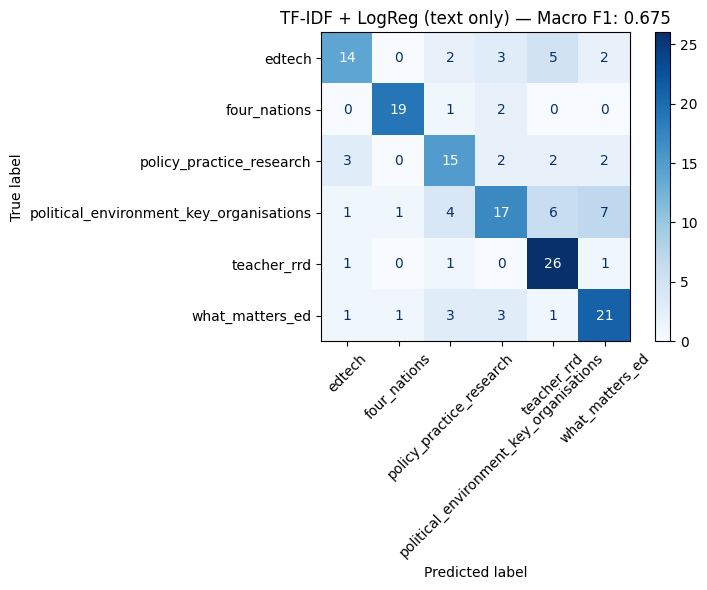

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_text_only, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"TF-IDF + LogReg (text only) — Macro F1: {macro_f1_text_only:.3f}")
plt.tight_layout()
plt.show()


In [14]:
# Get predicted probabilities for text-only model
y_proba_text_only = clf_text_only.predict_proba(X_val_tfidf)
classes_text_only = clf_text_only.classes_

# Top-k accuracy
for k in [1, 2]:
    top_k_preds = np.argsort(y_proba_text_only, axis=1)[:, -k:]
    top_k_correct = [
        np.where(classes_text_only == true)[0][0] in top_k
        for true, top_k in zip(y_val, top_k_preds)
    ]
    print(f"Top-{k} accuracy: {np.mean(top_k_correct):.3f}")

Top-1 accuracy: 0.671
Top-2 accuracy: 0.874


In [15]:
# Per-class top-2 accuracy
print("\nPer-class top-2 accuracy:\n")
for cls in classes_text_only:
    mask = y_val == cls
    top2_preds = np.argsort(y_proba_text_only[mask], axis=1)[:, -2:]
    cls_idx = np.where(classes_text_only == cls)[0][0]
    hit_rate = np.mean([cls_idx in row for row in top2_preds])
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")


Per-class top-2 accuracy:

  edtech                                        88%  (26 samples)
  four_nations                                  91%  (22 samples)
  policy_practice_research                      71%  (24 samples)
  political_environment_key_organisations       86%  (36 samples)
  teacher_rrd                                   97%  (29 samples)
  what_matters_ed                               90%  (30 samples)


In [16]:
# Show missed predictions
print("\n--- MISSED: true label not in top 2 ---\n")
for i in range(len(y_val)):
    true_label = y_val.iloc[i]
    top2_idx = np.argsort(y_proba_text_only[i])[-2:][::-1]
    top2 = [(classes_text_only[j], y_proba_text_only[i][j]) for j in top2_idx]

    if true_label not in [c for c, _ in top2]:
        print(f"True: {true_label}")
        print(f"  1. {top2[0][0]} ({top2[0][1]:.2f})  2. {top2[1][0]} ({top2[1][1]:.2f})")
        print(f"  Text: {val_df.iloc[i]['text_clean'][:150]}")
        print()



--- MISSED: true label not in top 2 ---

True: teacher_rrd
  1. policy_practice_research (0.40)  2. political_environment_key_organisations (0.16)
  Text: Ofsted: what scrapping single-word inspection grades will mean for teachers Rachel Harding, Research Fellow in Social Sciences, Nottingham Trent Unive

True: four_nations
  1. political_environment_key_organisations (0.28)  2. what_matters_ed (0.17)
  Text: Government devolution bill - 'Devolution Revolution' forges ahead with more powers for Mayors Raft of new powers will enable Mayors to drive economic 

True: what_matters_ed
  1. edtech (0.19)  2. teacher_rrd (0.19)
  Text: The Conversation - Too many students drop out of A-levels – here's how to help them pick a course they'll stick with Nigel Newton discusses his recent

True: policy_practice_research
  1. edtech (0.47)  2. political_environment_key_organisations (0.21)
  Text: NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is like

In [21]:
#Quick check on top 3
top3_preds = np.argsort(y_proba_text_only, axis=1)[:, -3:]
top3_correct = [
    np.where(classes_text_only == true)[0][0] in top3
    for true, top3 in zip(y_val, top3_preds)
]
print(f"Top-3 accuracy: {np.mean(top3_correct):.3f}")


Top-3 accuracy: 0.940


#### Top-3 accuracy is 94% (up from 89% with metadata) — the model almost always "knows" the right answer, it's just not always ranked first. Sticking with top-2 (87%) for the pipeline as the extra 7% doesn't justify a third option for the curator.


### Text-only evaluation: interpretation

**Overall improvement:**

| | Text+meta | Text-only | Change |
|---|---|---|---|
| Top-1 | 62% | 67% | +5% |
| Top-2 | 82% | 87% | +5% |

Text-only is better on every metric. New baseline: **0.675 macro F1, 87% top-2 accuracy**.

**Per-class top-2 accuracy:**

| Class | Top-2 (meta) | Top-2 (text-only) | Change |
|---|---|---|---|
| `edtech` | 73% | 88% | +15% |
| `four_nations` | 95% | 91% | -4% |
| `policy_practice_research` | 75% | 71% | -4% |
| `political_environment` | 72% | 86% | +14% |
| `teacher_rrd` | 93% | 97% | +4% |
| `what_matters_ed` | 87% | 90% | +3% |

The two weakest classes (`edtech` +15%, `political_environment` +14%) improved the most — metadata was pushing the model to classify by source rather than topic. Classes that dipped slightly (`four_nations` -4%, `policy_practice_research` -4%) are ones where metadata gave a genuine signal (e.g. Scottish/Welsh government sources). The tradeoff is worth it — gains on weak classes far outweigh small dips on already-strong classes.

**Missed predictions:** 21 missed (down from 30 with metadata), same pattern — articles at category boundaries that could legitimately belong to multiple classes. TF-IDF can't distinguish "DfE ends funding for teaching school hubs" (political_environment) from "DfE trials AI tutoring" (edtech) because it treats each keyword independently. Semantic models should help by understanding overall meaning.

**Next steps:**  For later models, metadata might help differently - test both for each model as planned.

# 8. Calibration check

Are the model's confidence scores meaningful? If the model says 0.70, is it actually right ~70% of the time? Dots on the diagonal = well calibrated.

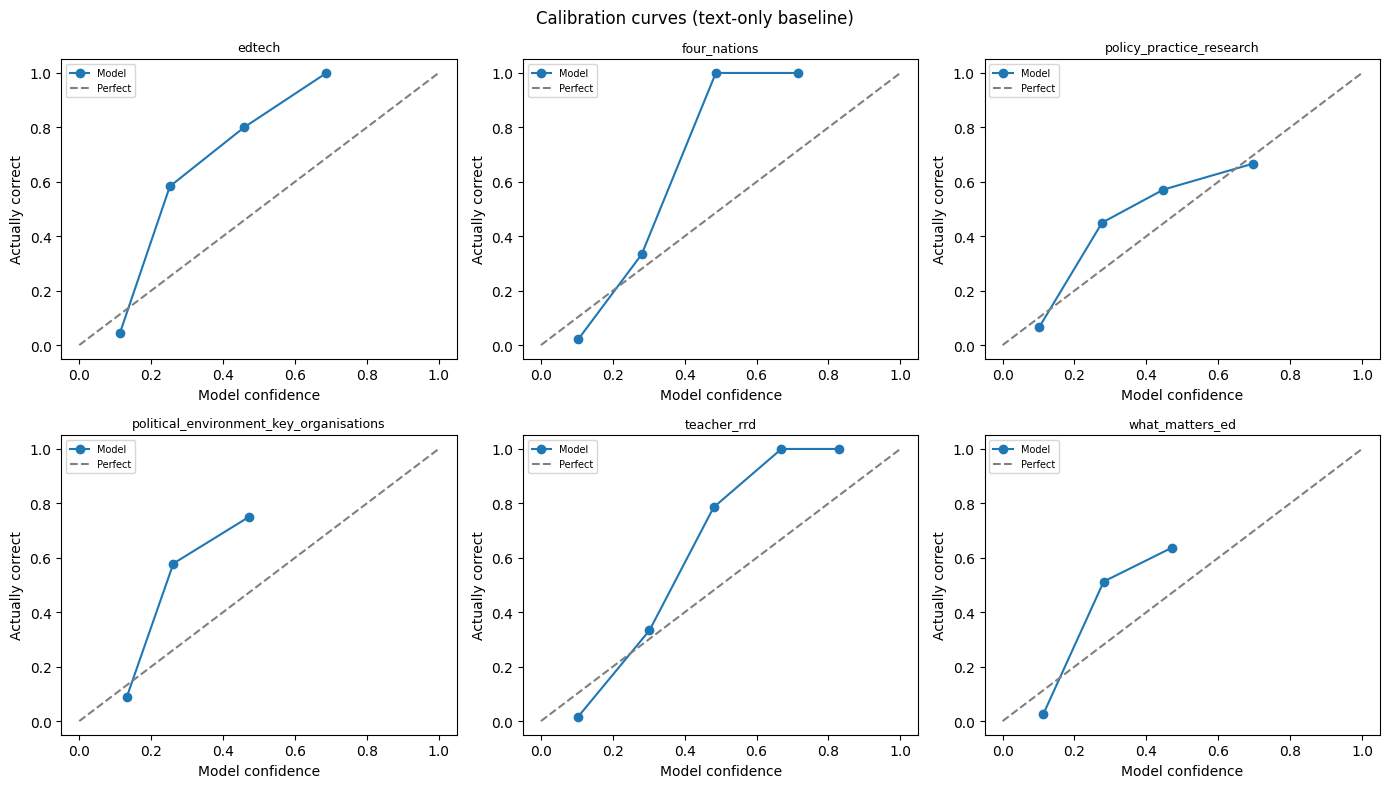

In [18]:
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(classes_text_only):
    mask = (y_val == cls).astype(int)
    prob_true, prob_pred = calibration_curve(
        mask,
        y_proba_text_only[:, i],
        n_bins=5,
        strategy="uniform",
    )

    axes[i].plot(prob_pred, prob_true, marker="o", label="Model")
    axes[i].plot([0, 1], [0, 1], "--", color="grey", label="Perfect")
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_xlabel("Model confidence")
    axes[i].set_ylabel("Actually correct")
    axes[i].legend(fontsize=7)

plt.suptitle("Calibration curves (text-only baseline)")
plt.tight_layout()
plt.show()


#### The model is underconfident — when it says 0.40, it's actually right more often than 40% of the time. This is the safe direction for the curator tool: the confidence scores are usable as-is with no calibration fix needed, though the curves are noisy with only 167 val samples.


# 9. Top features per class

Inspect the highest-weighted TF-IDF terms for each target class to check the model is learning sensible patterns.

In [19]:
feature_names = tfidf.get_feature_names_out().tolist()
TOP_N = 15

for i, cls in enumerate(clf_text_only.classes_):
    coefs = clf_text_only.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    top_features = [(feature_names[j], coefs[j]) for j in top_idx]

    print(f"\n--- {cls} ---")
    for feat, weight in top_features:
        print(f"  {weight:+.3f}  {feat}")


--- edtech ---
  +3.236  digital
  +1.865  use
  +1.864  edtech
  +1.347  online
  +1.321  generative
  +1.272  artificial
  +1.249  intelligence
  +1.189  tech
  +1.047  artificial intelligence
  +1.003  ban
  +0.962  social media
  +0.961  technology
  +0.953  regulation
  +0.869  media
  +0.869  phone

--- four_nations ---
  +2.800  scottish
  +2.518  wales
  +2.386  welsh
  +2.279  scotland
  +1.961  welsh government
  +1.841  scottish government
  +1.822  belfast
  +1.720  belfast telegraph
  +1.690  telegraph
  +1.673  northern
  +1.611  northern ireland
  +1.574  ireland
  +1.456  minister
  +1.214  education minister
  +1.084  learning

--- policy_practice_research ---
  +2.489  research
  +2.309  policy
  +1.187  universities
  +1.161  upen
  +1.129  knowledge
  +1.121  university
  +1.025  engagement
  +0.948  innovation
  +0.899  ippo
  +0.854  blog
  +0.852  place
  +0.842  local
  +0.841  evidence
  +0.821  science
  +0.764  making

--- political_environment_key_organisat

#### Top features confirm the model learns sensible patterns — `four_nations` and `teacher_rrd` have strong distinctive vocabulary, while `political_environment` relies on broad terms (ofsted, labour, curriculum) and source names (schoolsweek) that overlap with other categories. Consistent with the per-class performance: distinctive vocabulary = high recall, overlapping vocabulary = low recall.


# 10. Save model artefacts

In [20]:
joblib.dump(clf_text_only, MODEL_DIR / "baseline_logreg.joblib")
joblib.dump(tfidf, MODEL_DIR / "baseline_tfidf.joblib")

print(f"Saved to {MODEL_DIR}/")
print(f"  baseline_logreg.joblib  (text-only model)")
print(f"  baseline_tfidf.joblib")

Saved to ../models/
  baseline_logreg.joblib  (text-only model)
  baseline_tfidf.joblib


# Summary & Conclusions

## Baseline results

| Metric | Text + metadata | Text-only (final) |
|--------|----------------|-------------------|
| Macro F1 | 0.611 | **0.675** |
| Top-1 accuracy | 62% | 67% |
| Top-2 accuracy | 82% | 87% |
| Top-3 accuracy | 89% | 94% |

## Key findings

**Text-only outperforms text + metadata.** Adding one-hot encoded `item_type` and `org_broad_category` hurt performance by 6.5 points. TF-IDF already captures the signal from distinctive vocabulary, and metadata added source-level bias (e.g. `schoolsweek` became a top feature for `political_environment` despite Schools Week covering all topics).

**Top-2 predictions are the right approach for the pipeline.** 87% top-2 accuracy means the curator sees the correct category in 2 suggestions most of the time — up from 67% with a single prediction. Even the weakest class (`policy_practice_research`, 71% top-2) benefits significantly.

**Per-class performance varies with vocabulary distinctiveness:**
- Strong: `teacher_rrd` (97% top-2), `four_nations` (91%) — clear, distinctive keywords
- Moderate: `what_matters_ed` (90%), `edtech` (88%)
- Weaker: `political_environment` (86%), `policy_practice_research` (71%) — broad vocabulary that overlaps other categories

**Remaining misses (21/167) are genuinely ambiguous articles** that sit at category boundaries. TF-IDF treats keywords independently and can't distinguish "Ofsted reviewing AI" (edtech) from "Ofsted reviewing schools" (political_environment). This is the ceiling for keyword-based models.

## Decisions

- **Baseline benchmark: 0.675 macro F1, 87% top-2 accuracy** — later models must beat this
- **Pipeline output: top 2 categories with confidence scores** — curator confirms or overrides
- **Test text-only vs text+metadata for every subsequent model** — metadata may help embedding-based models differently
- **Recall matters more than precision** for this use case — better to over-suggest than to miss articles

## Saved artefacts

- `models/baseline_logreg.joblib` — text-only logistic regression
- `models/baseline_tfidf.joblib` — fitted TF-IDF vectoriser

**Next:** `04_sentence_transformer.ipynb` — sentence embeddings + classifier head
